### 2D Forward $NVT$ Simualtion with Patchy Particles
In this sample script, we demonstrate how to create patchy particles with different geometries and patch types using the `rigid_body` class in JAX-MD and run forward MD simulations. Throughout the script, we will provide helper functions to reconstruct the full patchy particle using the position and orientation of the center of mass of the patchy particle, and showcase how to use $\psi_k$ order parameters to measure the formation of either a triangular or a square lattice.

#### 1. Standard Import

In [1]:
import numpy as onp

from jax import config
config.update('jax_enable_x64', True)

import jax.numpy as jnp
from jax import random, jit, lax, vmap, jacfwd, remat
from jax.example_libraries import optimizers

import time
import os
from jax_md import space, smap, energy, minimize, quantity, simulate, rigid_body

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.collections import EllipseCollection
import seaborn as sns

sns.set_style(style='white')

def format_plot(x, y):
  plt.xlabel(x, fontsize=20)
  plt.ylabel(y, fontsize=20)

def finalize_plot(shape=(1, 1)):
  plt.gcf().set_size_inches(
    shape[0] * 1.5 * plt.gcf().get_size_inches()[1],
    shape[1] * 1.5 * plt.gcf().get_size_inches()[1],
  )
  plt.tight_layout()

#### 2. Loss Function ($\psi_k$)
For detailed explanation of how to use $\psi_k$, see notebook `loss_functions.ipynb`.

In [2]:
def get_psi_k(displacement_all, k=6, r0=1.1, alpha=100):

  def weight(r, r0=1.1, alpha=100):
    return jnp.where(r<1e-7, 0., 1.0/(1 + jnp.exp(alpha*(r - r0))))

  i_imaginary = complex(0,1)
  def get_ylms(dR_ij):
    epsilon = 0.00001 #avoids nan in derivative
    dR_ij = jnp.where(dR_ij==0.0, epsilon, dR_ij)
    theta = jnp.arctan2(dR_ij[1], dR_ij[0])
    return jnp.exp(i_imaginary*k*theta)

  def calculate_order_param(R):
    v_get_ylms = vmap(vmap(get_ylms))
    ds = displacement_all(R, R)
    r = space.distance(ds)
    w = weight(r, r0=r0, alpha=alpha)
    psi_k = (jnp.sum(v_get_ylms(ds)*w, axis=0)/(jnp.sum(w, axis=0)+0.00001))
    return psi_k

  def average_order_param(R):
    psi_k = calculate_order_param(R)
    return jnp.abs(jnp.mean(psi_k))

  return average_order_param

#### 3. Structure Builder Helper Function
For detailed explanation of how to use the 2D/3D structure initializer, see notebook `structures_init.ipynb`.

In [3]:
def make_2D_lattice_from_index_list(index_list,
                                    a0=jnp.array([jnp.sqrt(2),0.0]),
                                    a1=jnp.array([0.0,jnp.sqrt(2)]),
                                    unitcell=lambda a0, a1: jnp.array([[0.0, 0.0],
                                                                      a0,
                                                                      a1]),
                                    lattice_constant=lambda a0, a1, i, j: jnp.array([[i*a0+j*a1]]),
                                    offset=jnp.array([0.0,0.0])):
  unitcell_particles = unitcell(a0, a1) + offset 
  N = len(unitcell_particles)*index_list.shape[0]
  def get_cell(i,j):
    cell_shift = lattice_constant(a0, a1, i, j)
    return unitcell_particles + cell_shift

  return jnp.reshape(vmap(get_cell, in_axes=(0, 0))(index_list[:,0],index_list[:,1]),(N,2))

def make_2D_lattice(irange, jrange, **kwargs):
  index_list = jnp.array([ [i,j] for i in irange for j in jrange])
  return make_2D_lattice_from_index_list(index_list, **kwargs)

#### 4. Rigid Body Setup Helper Functions
Here we simulate a type of patchy particles where the center circle serves as the body, and patches around the body particle serve as the interaction sites. Here, we consider the patches massless. 
* We use angles (`thetas`) to define the location of the patches, the first patch is always at `[1, 0]` in the rigid body reference frame.
* All patches can be the same species or different species, we use `species` to define the species of all patches. The body particle will always have species 0, and the patch species start at 1.
* `radius` defines the size of the body particle
* `center_mass` defines the mass of the body particle
* `patch_mass` defines the mass of the patches, for most of the simulation considered here, they are practically massless.

In [9]:
@jit
def thetas_to_shape(thetas, species, radius=0.5, center_mass=1.0, patch_mass=1e-5):
  # Convert angles to patch positions
  patch_positions = jnp.zeros((len(thetas), 2), dtype = jnp.float64)
  patch_positions = patch_positions.at[:,0].set(radius*jnp.cos(thetas))
  patch_positions = patch_positions.at[:,1].set(radius*jnp.sin(thetas))

  # Add the central particle (position (0, 0)) to the list of positions
  central_particle_position = jnp.array([[0.0, 0.0]])
  positions = jnp.concatenate((central_particle_position, patch_positions), axis=0)

  if not len(thetas)+1 == len(species):
    raise ValueError("Must provide species information for every particle")

  # Combine positions and species to form a patchy particle rigid_body object
  masses = jnp.array([center_mass] + len(thetas)*[patch_mass])
  shape = rigid_body.point_union_shape(positions, masses).set(point_species=species)
  return shape

`body_to_plot` helps us recover the positions of all particles and group positions for the same patch species in the simulation for the ease of plot. During the simulation, the only position information recorded are the center of mass particles position and orientation.

In [10]:
def body_to_plot(body, thetas, species, radius=0.5):
  shape = thetas_to_shape(thetas, species, radius=radius)
  body_pos = vmap(rigid_body.transform, (0, None))(body, shape)
  bodypos = body_pos.reshape(-1, 2)
  species_list = jnp.array(list(species) * len(body.center))

  inds_at_id = lambda id: jnp.squeeze(jnp.argwhere(species_list==id))
  center_particles = bodypos[inds_at_id(0)]
  list_of_patch_particles = []
  for i in range(1, len(species)):
    list_of_patch_particles += [bodypos[inds_at_id(i)]]

  return center_particles, list_of_patch_particles

#### 5. Setting Up the Simulation
Here, we will set up a simulation with 100 patchy particles, each has four patches at $\theta = [0, 90, 180, 270]$. 

We will initialize the system on a dilute 10x10 ($M$) square lattice with lattice spacings $A0, A1 = 2.0, 2.0$.

The simulation will have a number density $\rho=0.2$.

Our goal is to assemble a square lattice, and we will start with a naive guess of all patches with the same species.

In [59]:
### Global Parameters
M = 10
A0 = 2.0
A1 = 2.0
UNITCELL_SQ = lambda a0, a1: jnp.array([[0.0,0.0]])
LATTICE_CONSTANT_SQ = lambda a0, a1, i, j: jnp.array([[i*a0+j*a1]])
UNITCELL_SQ = jit(UNITCELL_SQ)
LATTICE_CONSTANT_SQ = jit(LATTICE_CONSTANT_SQ)
N = M**2
DIMENSION = 2

RHO = 0.2
BOX_SIZE = (N/RHO)**(1/2)

kT = 0.2
dt = 1e-3
RADIUS = 0.5
R0 = RADIUS*2*1.1
THETAS = jnp.array([0, jnp.pi/2.0, jnp.pi, jnp.pi*3/2.0])
SPECIES = jnp.array([0, 1, 1, 1, 1], dtype = jnp.int32)
NUM_SPECIES = len(set(list(onp.array(SPECIES))))

key=random.PRNGKey(32)

In [43]:
R = (make_2D_lattice)(jnp.arange(0,M),jnp.arange(0,M),
                      a0=jnp.array([A0,0.0]),
                      a1=jnp.array([0.0,A1]),
                      unitcell= UNITCELL_SQ,
                      lattice_constant=LATTICE_CONSTANT_SQ,
                      offset=jnp.array([0.01, 0.03]))

Here, we will visualize the initialization setup for our system. First, the body particles only, and then the full patchy particle realization.

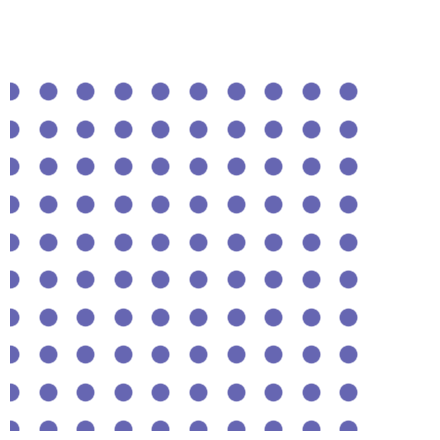

In [63]:
fig, ax = plt.subplots()
fig.set_size_inches(3, 3)
ax.add_collection(EllipseCollection(widths=1.0, heights=1.0, angles=0, units='xy',
                                       facecolors='navy', alpha = 0.6, 
                                       offsets=list(R), transOffset=ax.transData))
plt.xlim([0, BOX_SIZE])
plt.ylim([0, BOX_SIZE])
plt.axis('off')
finalize_plot((1, 1))

In [45]:
# Conver to rigid body object
patchy_particle_shape = thetas_to_shape(THETAS, SPECIES)

# Choose random orientations for each patchy particle
angle_key, split = random.split(key)
orientations = random.uniform(angle_key, (len(R),), dtype=jnp.float64) * jnp.pi * 2

# Combine orientations with square lattice positions
full_configuration = rigid_body.RigidBody(R, orientations)
     

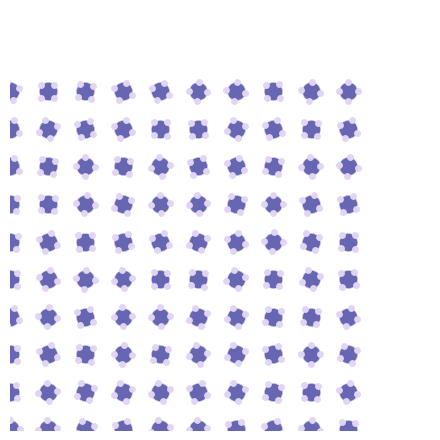

In [52]:
fig, ax = plt.subplots()
fig.set_size_inches(3, 3)
center_pos, patches_pos = body_to_plot(full_configuration, THETAS, SPECIES)
patches_color = ['#e1d4f4', '#ffde9f', '#ffdfee', '#bfede6', '#f6fca6']
ax.add_collection(EllipseCollection(widths=1.0, heights=1.0, angles=0, units='xy',
                                       facecolors='navy', alpha = 0.6, 
                                       offsets=list(center_pos), transOffset=ax.transData))
for i in range(1, NUM_SPECIES):
  ax.add_collection(EllipseCollection(widths=0.29, heights=0.29, angles=0, units='xy',
                                      facecolors=patches_color[i-1], edgecolors=patches_color[i-1], alpha = 1.0, 
                                      offsets=list(patches_pos[i-1]), transOffset=ax.transData))
plt.xlim([0, BOX_SIZE])
plt.ylim([0, BOX_SIZE])
plt.axis('off')
finalize_plot((1, 1))

Here, we define our pair potentials and integrator to run the simulation.
* We use `soft_sphere` potential to define the excluded volume of the body particle.
* We use `morse` potential to define the attractiveness of the patches
    * `sigma` defines the minimum of the `morse` potential well. Here we assume our patches interact by fully overlap, so `sigma=0`.
    * `alpha` defines the steepness of the `morse` potential, representing the interaction range of the patches. `alpha=9.0` roughly represents an interaction range of 0.29.

In [53]:
displacement, shift = space.periodic(BOX_SIZE)
key, split = random.split(key)

soft_eps = jnp.zeros((2, 2))
soft_eps = soft_eps.at[0, 0].set(10000.0)
morse_eps = jnp.zeros((2, 2))
morse_eps = morse_eps.at[1, 1].set(4.0)
energy_fn_soft = energy.soft_sphere_pair(displacement, species = 2, sigma = RADIUS*2, epsilon = soft_eps, alpha = 4.0)
energy_fn_morse = energy.morse_pair(displacement, species = 2, sigma = 0.0, epsilon = morse_eps, alpha = 9.0, r_cutoff = 1.5)
energy_fn_all = lambda R, **kwargs: energy_fn_soft(R, **kwargs) + energy_fn_morse(R, **kwargs)
energy_fn = rigid_body.point_energy(energy_fn_all, patchy_particle_shape)

init, apply = simulate.nvt_nose_hoover(energy_fn, shift, dt, kT = kT)
step = jit(lambda i, state: apply(state))
state = init(key, full_configuration, mass=patchy_particle_shape.mass())

#### 6. Running the Simulation
Here, we will run the simulation for a total of `N_stepsxinner_steps=1000x100=1e5` steps. 

We will also record the following thermodynamics variables:
* Potential Energy (`PE`): this can be directly calculated using `energy_fn`
* Kinetic Energy (`KE`): we need to use the `rigid_body.kinetic_energy` function instead of the `quantity.kinetic_energy` as we have rotational degree of freedom. We will need to provide `position, moment, mass` data for correct computation.
* Temperature (`T`): we need to use the `rigid_body.temperature` function instead of the `quantity.temperature` as we have rotational degree of freedom. We will need to provide `position, moment, mass` data for correct computation.
* `loss`: we will record $\psi_4$ order parameter along the simulation
* `trajectory`: position data of the body particle

In [54]:
displacement_all = vmap(vmap(displacement, (0, None), 0), (None, 0), 0)
order_param = get_psi_k(displacement_all, k=4, r0=R0, alpha=100)

PE = [energy_fn(state.position)]
KE = [rigid_body.kinetic_energy(position=state.position, momentum=state.momentum, mass=patchy_particle_shape.mass())]
T = [rigid_body.temperature(position=state.position, momentum=state.momentum, mass=patchy_particle_shape.mass())]
loss = [order_param(state.position.center)]
trajectory = [state.position]

N_steps = 1000
inner_steps = 100
print_every = 100
old_time = time.time()
print('Step\tKE\tPE\tTotal Energy\ttime/step')
print('----------------------------------------')

for i in range(N_steps):
  state = lax.fori_loop(0, inner_steps, step, state)

  PE += [energy_fn(state.position)]
  KE += [rigid_body.kinetic_energy(position=state.position, momentum=state.momentum, mass=patchy_particle_shape.mass())]
  T += [rigid_body.temperature(position=state.position, momentum=state.momentum, mass=patchy_particle_shape.mass())]
  loss += [order_param(state.position.center)]
  trajectory += [state.position]

  if i % print_every == 0 and i > 0:
    new_time = time.time()
    print(
      '{}\t{:.2f}\t{:.2f}\t{:.3f}\t{:.3f}'.format(
        i * inner_steps,
        KE[-1],
        PE[-1],
        KE[-1] + PE[-1],
        (new_time - old_time) / print_every / inner_steps,
      )
    )
    old_time = new_time

PE = jnp.array(PE)
KE = jnp.array(KE)
T = jnp.array(T)
loss = jnp.array(loss)

Step	KE	PE	Total Energy	time/step
----------------------------------------
10000	25.96	-273.68	-247.716	0.008
20000	31.17	-335.33	-304.158	0.008
30000	24.41	-370.65	-346.238	0.008
40000	27.85	-376.81	-348.952	0.008
50000	32.06	-388.53	-356.473	0.008
60000	31.74	-399.40	-367.663	0.008
70000	29.07	-408.59	-379.516	0.008
80000	30.63	-421.41	-390.774	0.008
90000	30.99	-438.36	-407.374	0.008


#### 7. Visualize the Results

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2415/1828304066.py:17: SyntaxWarning: invalid escape sequence '\p'
  axs[2].set_ylabel('$\psi_4$', fontsize = 18)


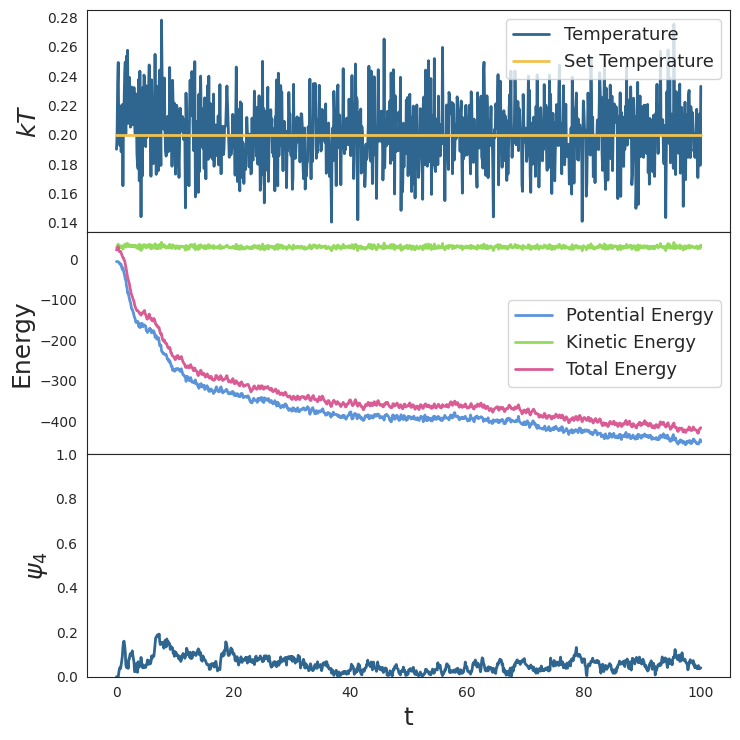

In [55]:
t = onp.arange(0, N_steps+1) * dt * inner_steps

fig = plt.figure(figsize = (8, 5))
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True)

axs[0].plot(t, T, label = 'Temperature', color = '#2f6690', linewidth = 2)
axs[0].plot(t, onp.ones(len(t))*0.2, color = '#f2c14e', label = 'Set Temperature', linewidth = 2)
axs[0].legend(fontsize = 13)
axs[0].set_ylabel('$kT$', fontsize = 18)
axs[1].plot(t, PE, label='Potential Energy', color = '#5c94da', linewidth = 2)
axs[1].plot(t, KE, label='Kinetic Energy', color = '#94da5c', linewidth = 2)
axs[1].plot(t, PE + KE, label='Total Energy', color = '#da5c94', linewidth = 2)
axs[1].legend(fontsize = 13)
axs[1].set_ylabel('Energy', fontsize = 18)
axs[2].plot(t, loss, color = '#2f6690', linewidth = 2)
axs[2].set_ylabel('$\psi_4$', fontsize = 18)
axs[2].set_ylim(0.0, 1.0)
axs[2].set_xlabel('t', fontsize = 18)
finalize_plot()

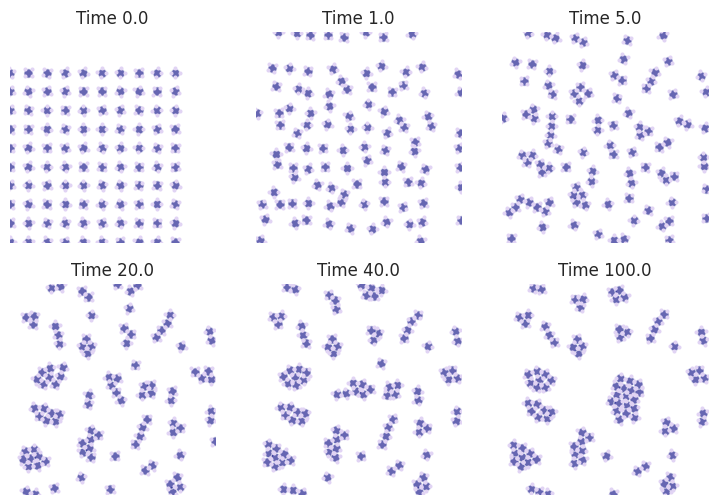

In [61]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(9, 6)
index = [0, 10, 50, 200, 400, 1000]
patches_color = ['#e1d4f4', '#ffde9f', '#ffdfee', '#bfede6', '#f6fca6']
for i in range(2):
  for j in range(3):
    center_pos, patches_pos = body_to_plot(trajectory[index[i*3+j]], THETAS, SPECIES)

    axs[i, j].add_collection(EllipseCollection(widths=1.0, heights=1.0, angles=0, units='xy',
                                           facecolors='navy', alpha = 0.6, 
                                           offsets=list(center_pos), transOffset=axs[i, j].transData))
    for k in range(1, NUM_SPECIES):
      axs[i, j].add_collection(EllipseCollection(widths=0.29, heights=0.29, angles=0, units='xy',
                                      facecolors=patches_color[k-1], edgecolors=patches_color[k-1], alpha = 1.0, 
                                      offsets=list(patches_pos[k-1]), transOffset=axs[i, j].transData))

    axs[i, j].set_xlim([0, BOX_SIZE])
    axs[i, j].set_ylim([0, BOX_SIZE])
    axs[i, j].set_axis_off()
    axs[i, j].set_title("Time "+str(index[i*3+j]*dt*inner_steps))

#### 8. Simulation with 4 Types of Patches
From the previous simulation, we see that one type of patch is not enough to promote square lattice formation. Now let's try it with four different type of patches.

In [71]:
### Global Parameters
M = 10
A0 = 2.0
A1 = 2.0
UNITCELL_SQ = lambda a0, a1: jnp.array([[0.0,0.0]])
LATTICE_CONSTANT_SQ = lambda a0, a1, i, j: jnp.array([[i*a0+j*a1]])
UNITCELL_SQ = jit(UNITCELL_SQ)
LATTICE_CONSTANT_SQ = jit(LATTICE_CONSTANT_SQ)
N = M**2
DIMENSION = 2

RHO = 0.2
BOX_SIZE = (N/RHO)**(1/2)

kT = 0.2
dt = 1e-3
RADIUS = 0.5
R0 = RADIUS*2*1.1
THETAS = jnp.array([0, jnp.pi/2.0, jnp.pi, jnp.pi*3/2.0])
SPECIES = jnp.array([0, 1, 2, 3, 4], dtype = jnp.int32)
NUM_SPECIES = len(set(list(onp.array(SPECIES))))

key=random.PRNGKey(48)

R = (make_2D_lattice)(jnp.arange(0,M),jnp.arange(0,M),
                      a0=jnp.array([A0,0.0]),
                      a1=jnp.array([0.0,A1]),
                      unitcell= UNITCELL_SQ,
                      lattice_constant=LATTICE_CONSTANT_SQ,
                      offset=jnp.array([0.01, 0.03]))

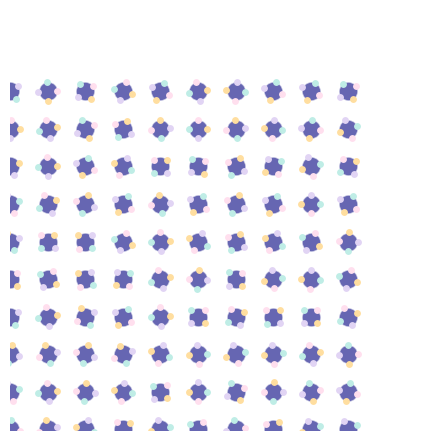

In [72]:
# Conver to rigid body object
patchy_particle_shape = thetas_to_shape(THETAS, SPECIES)

# Choose random orientations for each patchy particle
angle_key, split = random.split(key)
orientations = random.uniform(angle_key, (len(R),), dtype=jnp.float64) * jnp.pi * 2

# Combine orientations with square lattice positions
full_configuration = rigid_body.RigidBody(R, orientations)

fig, ax = plt.subplots()
fig.set_size_inches(3, 3)
center_pos, patches_pos = body_to_plot(full_configuration, THETAS, SPECIES)
patches_color = ['#e1d4f4', '#ffde9f', '#ffdfee', '#bfede6', '#f6fca6']
ax.add_collection(EllipseCollection(widths=1.0, heights=1.0, angles=0, units='xy',
                                       facecolors='navy', alpha = 0.6, 
                                       offsets=list(center_pos), transOffset=ax.transData))
for i in range(1, NUM_SPECIES):
  ax.add_collection(EllipseCollection(widths=0.29, heights=0.29, angles=0, units='xy',
                                      facecolors=patches_color[i-1], edgecolors=patches_color[i-1], alpha = 1.0, 
                                      offsets=list(patches_pos[i-1]), transOffset=ax.transData))
plt.xlim([0, BOX_SIZE])
plt.ylim([0, BOX_SIZE])
plt.axis('off')
finalize_plot((1, 1))

In [73]:
displacement, shift = space.periodic(BOX_SIZE)
key, split = random.split(key)

soft_eps = jnp.zeros((NUM_SPECIES, NUM_SPECIES))
soft_eps = soft_eps.at[0, 0].set(10000.0)
morse_eps = jnp.zeros((NUM_SPECIES, NUM_SPECIES))
morse_eps = morse_eps.at[1, 3].set(4.0)
morse_eps = morse_eps.at[3, 1].set(4.0)
morse_eps = morse_eps.at[2, 4].set(4.0)
morse_eps = morse_eps.at[4, 2].set(4.0)
energy_fn_soft = energy.soft_sphere_pair(displacement, species = NUM_SPECIES, sigma = RADIUS*2, epsilon = soft_eps, alpha = 4.0)
energy_fn_morse = energy.morse_pair(displacement, species = NUM_SPECIES, sigma = 0.0, epsilon = morse_eps, alpha = 9.0, r_cutoff = 1.5)
energy_fn_all = lambda R, **kwargs: energy_fn_soft(R, **kwargs) + energy_fn_morse(R, **kwargs)
energy_fn = rigid_body.point_energy(energy_fn_all, patchy_particle_shape)

init, apply = simulate.nvt_nose_hoover(energy_fn, shift, dt, kT = kT)
step = jit(lambda i, state: apply(state))
state = init(key, full_configuration, mass=patchy_particle_shape.mass())

In [74]:
displacement_all = vmap(vmap(displacement, (0, None), 0), (None, 0), 0)
order_param = get_psi_k(displacement_all, k=4, r0=R0, alpha=100)

PE = [energy_fn(state.position)]
KE = [rigid_body.kinetic_energy(position=state.position, momentum=state.momentum, mass=patchy_particle_shape.mass())]
T = [rigid_body.temperature(position=state.position, momentum=state.momentum, mass=patchy_particle_shape.mass())]
loss = [order_param(state.position.center)]
trajectory = [state.position]

N_steps = 1000
inner_steps = 100
print_every = 100
old_time = time.time()
print('Step\tKE\tPE\tTotal Energy\ttime/step')
print('----------------------------------------')

for i in range(N_steps):
  state = lax.fori_loop(0, inner_steps, step, state)

  PE += [energy_fn(state.position)]
  KE += [rigid_body.kinetic_energy(position=state.position, momentum=state.momentum, mass=patchy_particle_shape.mass())]
  T += [rigid_body.temperature(position=state.position, momentum=state.momentum, mass=patchy_particle_shape.mass())]
  loss += [order_param(state.position.center)]
  trajectory += [state.position]

  if i % print_every == 0 and i > 0:
    new_time = time.time()
    print(
      '{}\t{:.2f}\t{:.2f}\t{:.3f}\t{:.3f}'.format(
        i * inner_steps,
        KE[-1],
        PE[-1],
        KE[-1] + PE[-1],
        (new_time - old_time) / print_every / inner_steps,
      )
    )
    old_time = new_time

PE = jnp.array(PE)
KE = jnp.array(KE)
T = jnp.array(T)
loss = jnp.array(loss)

Step	KE	PE	Total Energy	time/step
----------------------------------------
10000	28.01	-166.85	-138.839	0.054
20000	26.68	-230.93	-204.248	0.054
30000	32.84	-282.05	-249.209	0.055
40000	30.32	-327.35	-297.024	0.057
50000	31.88	-358.54	-326.662	0.058
60000	28.68	-377.85	-349.162	0.060
70000	34.95	-390.63	-355.686	0.061
80000	26.07	-399.76	-373.687	0.062
90000	31.22	-397.94	-366.722	0.064


<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2415/1828304066.py:17: SyntaxWarning: invalid escape sequence '\p'
  axs[2].set_ylabel('$\psi_4$', fontsize = 18)


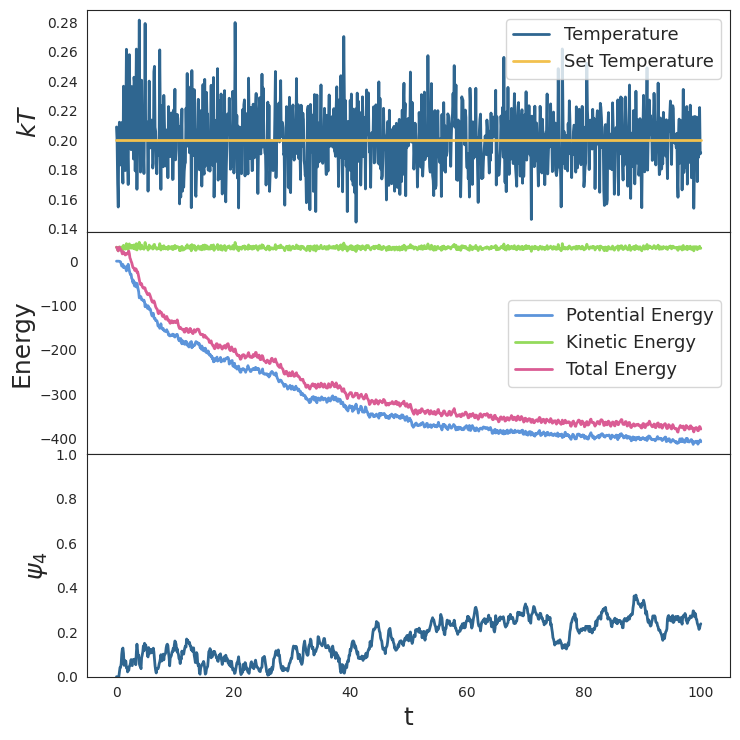

In [75]:
t = onp.arange(0, N_steps+1) * dt * inner_steps

fig = plt.figure(figsize = (8, 5))
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True)

axs[0].plot(t, T, label = 'Temperature', color = '#2f6690', linewidth = 2)
axs[0].plot(t, onp.ones(len(t))*0.2, color = '#f2c14e', label = 'Set Temperature', linewidth = 2)
axs[0].legend(fontsize = 13)
axs[0].set_ylabel('$kT$', fontsize = 18)
axs[1].plot(t, PE, label='Potential Energy', color = '#5c94da', linewidth = 2)
axs[1].plot(t, KE, label='Kinetic Energy', color = '#94da5c', linewidth = 2)
axs[1].plot(t, PE + KE, label='Total Energy', color = '#da5c94', linewidth = 2)
axs[1].legend(fontsize = 13)
axs[1].set_ylabel('Energy', fontsize = 18)
axs[2].plot(t, loss, color = '#2f6690', linewidth = 2)
axs[2].set_ylabel('$\psi_4$', fontsize = 18)
axs[2].set_ylim(0.0, 1.0)
axs[2].set_xlabel('t', fontsize = 18)
finalize_plot()

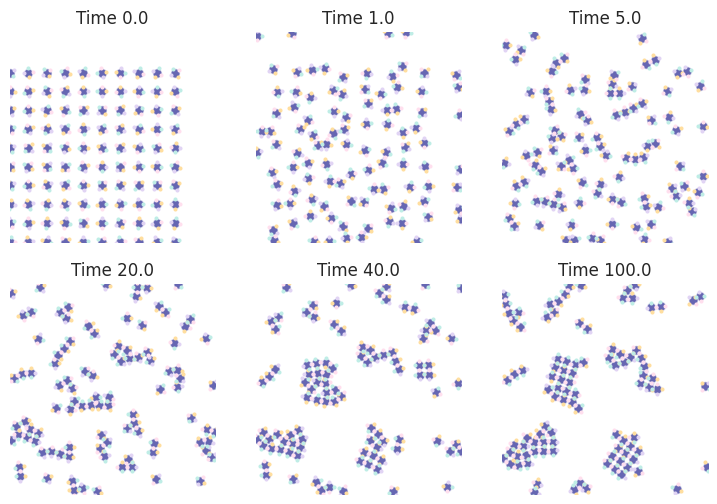

In [76]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(9, 6)
index = [0, 10, 50, 200, 400, 1000]
patches_color = ['#e1d4f4', '#ffde9f', '#ffdfee', '#bfede6', '#f6fca6']
for i in range(2):
  for j in range(3):
    center_pos, patches_pos = body_to_plot(trajectory[index[i*3+j]], THETAS, SPECIES)

    axs[i, j].add_collection(EllipseCollection(widths=1.0, heights=1.0, angles=0, units='xy',
                                           facecolors='navy', alpha = 0.6, 
                                           offsets=list(center_pos), transOffset=axs[i, j].transData))
    for k in range(1, NUM_SPECIES):
      axs[i, j].add_collection(EllipseCollection(widths=0.29, heights=0.29, angles=0, units='xy',
                                      facecolors=patches_color[k-1], edgecolors=patches_color[k-1], alpha = 1.0, 
                                      offsets=list(patches_pos[k-1]), transOffset=axs[i, j].transData))

    axs[i, j].set_xlim([0, BOX_SIZE])
    axs[i, j].set_ylim([0, BOX_SIZE])
    axs[i, j].set_axis_off()
    axs[i, j].set_title("Time "+str(index[i*3+j]*dt*inner_steps))